In [4]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

data_file = 'data/Feb2026_withInstZPs.csv'
t = Table.read(data_file, format='ascii.csv')

In [5]:
EMZPfile = Path('data/ExposureMeterZeroPoints.yaml')
with open(EMZPfile, 'r') as f:
    EMZeroPoint = yaml.safe_load(f)
EMZeroPoint

{1: 21.296749750531042,
 2: 21.802875631774594,
 3: 21.738583308861333,
 4: 21.385165124935046,
 'SUM': 23.06521519492087}

In [6]:
ZPfile = Path('data/InstrumentZeroPoints.yaml')
with open(ZPfile, 'r') as f:
    ZeroPoint = yaml.safe_load(f)
ZeroPoint

{'452': 13.664278495210038,
 '548': 14.964690898633878,
 '652': 15.329155098901115,
 '747': 15.466755734095996,
 '852': 15.073233551565435}

In [7]:
EMbinfile = Path('data/ExpMeterBins.yaml')
with open(EMbinfile, 'r') as f:
    best_EMbin = yaml.safe_load(f)
best_EMbin

{'452': 1, '548': 2, '652': 3, '747': 4, '852': 4}

# Build an ETC From the "Nominal" Zero Point Value

In [8]:
def ZPETC(Gmag, exptime, instwav='652', EMbin=2):
    assert instwav in ZeroPoint.keys()
    assert EMbin in EMZeroPoint.keys()
    photons = float(exptime*10**((Gmag - ZeroPoint[instwav])/-2.5))
    EM_ADU = float(exptime*10**((Gmag - EMZeroPoint[EMbin])/-2.5))
    return photons, EM_ADU


def EMThreshold(photons, instwav='652', EMbin=2):
    assert instwav in ZeroPoint.keys()
    assert EMbin in EMZeroPoint.keys()
    ZPdiff = ZeroPoint[instwav] - EMZeroPoint[EMbin]
    EM_ADU = photons*10**(-ZPdiff/2.5)
    return EM_ADU

In [9]:
photons, EMADU = ZPETC(10, 60, instwav='747', EMbin=3)
photons, EMADU

(9222.60363288268, 2975668.6802112367)

In [10]:
EMADU2 = EMThreshold(photons, instwav='747', EMbin=3)
EMADU2/EMADU

1.000000000000001

# Slowdown Factor

How well does the nominal flux estimate from our Zero Point based ETC predict the actual/measured flux in the data set?  To examine this, we look at the slowdown factor which is the ratio of the flux expected versus the flux measured.  The slowdown can be calculated for the instrument flux and for the Exposure Meter flux, so we want to see how well the Exposure Meter slowdown predicts the spectrograph slow down.

In [50]:
def plot_slowdowns(t, instwav):
    t = t[~t['TOTCORR'].mask]
    EMbin = best_EMbin[instwav]
    instfluxes = (t[f'SNRSC{instwav}'])**2 # photons / pix
    if EMbin == 'all':
        EMfluxes = t[f'TOTCORR_SUM']
    else:
        EMfluxes = t[f'TOTCORR_{EMbin}']
    
    Gmags = t['GAIAMAG']
    exptimes = t['ELAPSED']
    
    slowdowns = np.array([ZPETC(Gmags[i], exptimes[i], instwav=instwav, EMbin=EMbin)[0]/instfluxes[i] for i in range(len(t))])
    EMslowdowns = np.array([ZPETC(Gmags[i], exptimes[i], instwav=instwav, EMbin=EMbin)[1]/EMfluxes[i] for i in range(len(t))])

    bins = np.arange(0,10,0.1)
    
    plt.figure(figsize=(10,7))
    
    plt.subplot(4,1,1)
    plt.title(f'Instrument Slowdowns Calulated at {instwav} nm')
    plt.hist(slowdowns, bins=bins, density=True, color='b', label='Spectrograph')
    plt.axvline(1, color='k', alpha=0.5, label='Nominal')
    plt.axvspan(1, 2, color='g', alpha=0.2, label='band1')
    plt.axvspan(2, 4, color='y', alpha=0.2, label='band2')
    plt.grid()
    plt.legend(loc='best')
    plt.ylabel(f'Density (N={len(slowdowns)})')
    
    plt.subplot(4,1,2)
    plt.hist(EMslowdowns, bins=bins, density=True, color='g', label='ExpMeter')
    plt.axvline(1, color='k', alpha=0.5, label='Nominal')
    plt.axvspan(1, 2, color='g', alpha=0.2, label='band1')
    plt.axvspan(2, 4, color='y', alpha=0.2, label='band2')
    plt.grid()
    plt.legend(loc='best')
    plt.ylabel(f'Density (N={len(slowdowns)})')

    plt.subplot(4,1,3)
    plt.hist(EMslowdowns, bins=bins, density=True, color='g', cumulative=True, label='ExpMeter')
    plt.axvline(1, color='k', alpha=0.5, label='Nominal')
    plt.axvspan(1, 2, color='g', alpha=0.2, label='band1')
    plt.axvspan(2, 4, color='y', alpha=0.2, label='band2')
    plt.grid()
    plt.legend(loc='best')
    plt.xlabel('Slowdown Factor')
    plt.ylabel(f'Cumulative Density')
    
    plt.subplot(4,1,4)
    bins = np.arange(0,3,0.010)
    ratio = EMslowdowns/slowdowns
    n, srbins, foo = plt.hist(ratio, bins=bins, density=True, log=False, color='c')
    mode_ratio = srbins[np.argmax(n)]
    plt.axvline(mode_ratio, color='r', label=f'Typical={mode_ratio:.2f}')
    plt.axvline(1, color='k', label=f'Nominal=1')
    plt.grid()
    plt.legend(loc='best')
    plt.xlabel('Ratio: EMslowdown/slowdown')
    plt.ylabel(f'Density (N={len(slowdowns)})')
    plt.show()

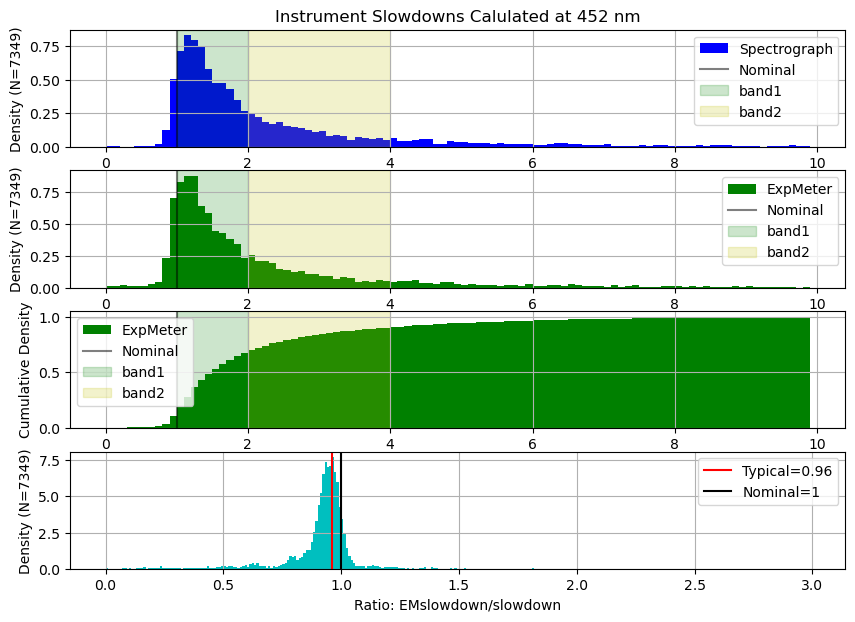

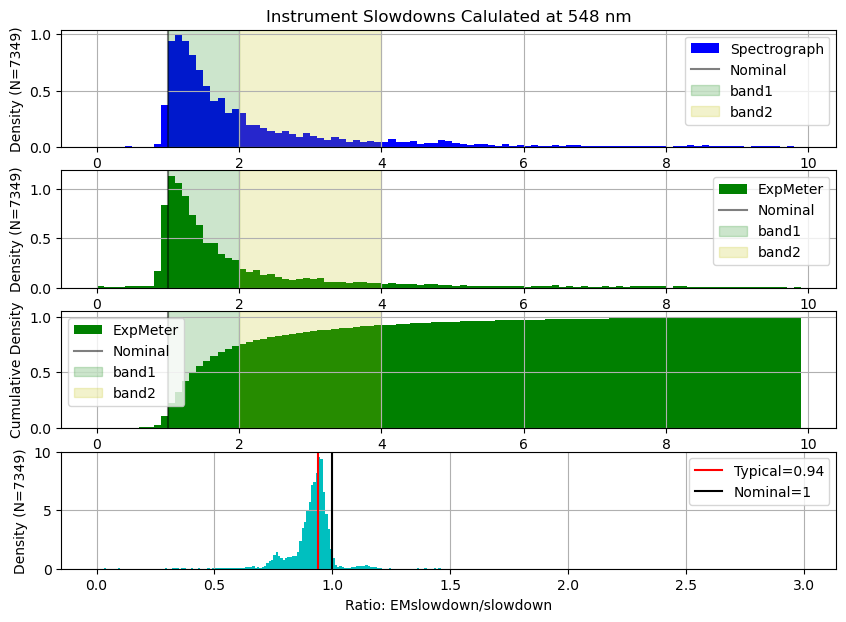

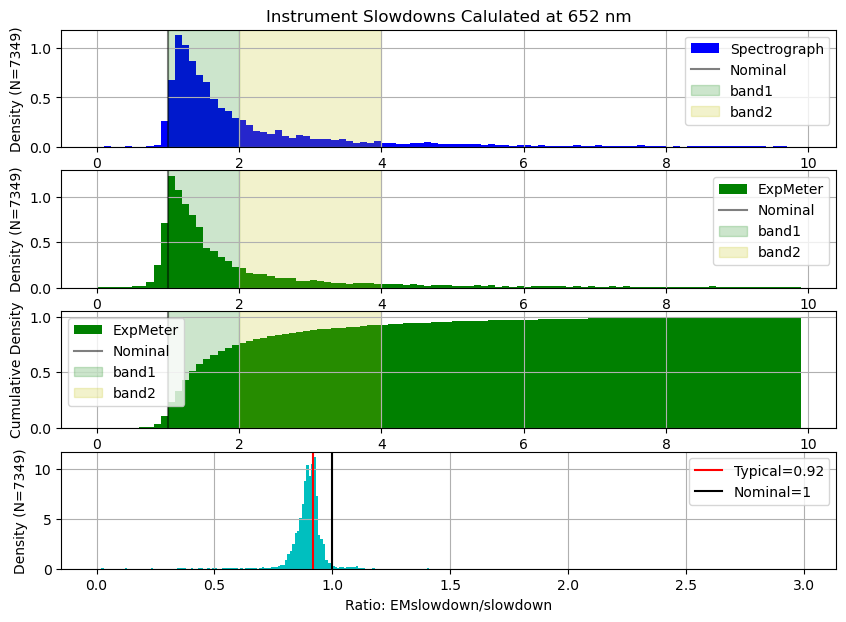

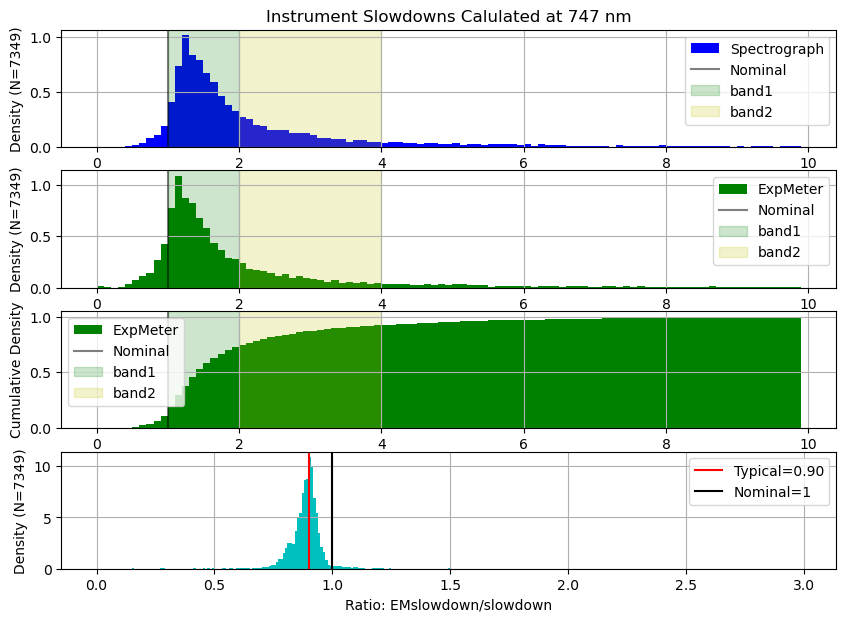

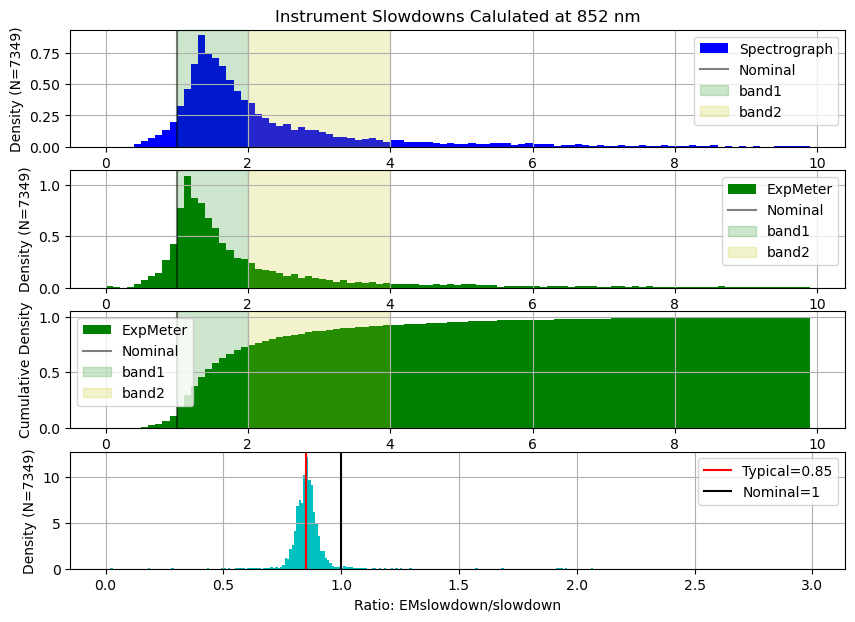

In [51]:
wavs = ['452', '548', '652', '747', '852']
for wav in wavs:
    plot_slowdowns(t, wav)

### Discussion

We see that the slowdown factors (for either the instrument or the exposure meter) are typically >1.  This is to be expected as our nominal zero points are the 90th percentile of good data, so the Zero Point ETC assumes very good condition, thus most data are taken in somewhat worse conditions.

The distribution of slowdowns is what we'd expect given the distribution of Zero Points we measured before.

We have highlighted the "band1" and "band2" weather bands as defined by their slowdown rate.  The cumulative plot shows that the majority of observations take place in band1 as we would expect.

Comparing the distribution of exposure meter slowdowns to instrument slow downs, we see that the exposure meter is typically a bit optimistic relative to the instrument by 10-15%, so the actual slowdown is a bit worse than one estimated in real time by the Exposure Meter.